# Hierarchical Clustering + SVM & Logistic Regression Hybrid
**Sam's section**: Does accounting for unsupervised structure improve supervised prediction?

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, f1_score, roc_auc_score, silhouette_score, davies_bouldin_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.neighbors import NearestCentroid

# EVERYONE SHOULD USE THIS SEED
RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='Set2')

## 1. Load & Prepare Data

In [25]:
df = pd.read_csv('data/startup_data_cleaned.csv')
print(f'Shape: {df.shape}')
display(df.head(10))

Shape: (923, 35)


,latitude,longitude,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,...,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,outcome,has_milestone
0,42.358880,-71.056820,2.2493,3.0027,4.6685,6.7041,3,3,375000,3,...,0,1,0,0,0,0,1.0000,0,acquired,1
1,37.238916,-121.973718,5.1260,9.9973,7.0055,7.0055,9,4,40100000,1,...,1,0,0,1,1,1,4.7500,1,acquired,1
2,32.901049,-117.192656,1.0329,1.0329,1.4575,2.2055,5,1,2600000,2,...,0,0,1,0,0,0,4.0000,1,acquired,1
3,37.320309,-122.050040,3.1315,5.3151,6.0027,6.0027,5,3,40000000,1,...,0,0,0,1,1,1,3.3333,1,acquired,1
4,37.779281,-122.419236,0.0000,1.6685,0.0384,0.0384,2,2,1300000,1,...,1,1,0,0,0,0,1.0000,1,closed,1
5,37.406914,-122.090370,4.5452,4.5452,5.0027,5.0027,3,1,7500000,1,...,0,0,0,1,0,0,3.0000,1,closed,1
6,37.391559,-122.070264,1.7205,5.2110,3.0000,6.6082,6,3,26000000,2,...,1,0,1,1,0,0,1.6667,1,acquired,1
7,38.057107,-122.513742,1.6466,6.7616,5.6055,7.3616,25,3,34100000,3,...,0,0,1,1,0,1,3.5000,1,acquired,1
8,42.712207,-73.203599,3.5863,11.1123,8.0055,9.9945,13,3,9650000,4,...,1,0,1,0,0,1,4.0000,1,acquired,1
9,37.427235,-122.145783,1.6712,4.6849,2.9178,6.1151,14,3,5750000,4,...,1,1,1,0,0,0,1.0000,1,acquired,1


In [26]:
X = df.drop(columns=['outcome'])
y = df['outcome']

le = LabelEncoder()
y = le.fit_transform(y)
print('Classes:', le.classes_)   # 0 = acquired/success, 1 = closed/failed (check order)

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}')

Classes: ['acquired' 'closed']
Train: (646, 34), Val: (138, 34), Test: (139, 34)


## 2. Baseline Models (no clustering)
Train LR and SVM on raw scaled features as the comparison point.

In [27]:
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_base.fit(X_train_scaled, y_train)

svm_base = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_base.fit(X_train_scaled, y_train)

print('Baseline models trained.')

def evaluate(name, model, X, y):
    """Print classification metrics and return a summary dict."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    f1     = f1_score(y, y_pred, average='macro')
    auc    = roc_auc_score(y, y_prob)
    print(f'\n=== {name} ===')
    print(classification_report(y, y_pred, target_names=le.classes_))
    print(f'F1 Macro: {f1:.4f}   ROC-AUC: {auc:.4f}')
    return {'Model': name, 'F1 Macro': f1, 'ROC-AUC': auc}

results = []
results.append(evaluate('LR  (baseline)',  lr_base,  X_test_scaled, y_test))
results.append(evaluate('SVM (baseline)', svm_base, X_test_scaled, y_test))

Baseline models trained.

=== LR  (baseline) ===
              precision    recall  f1-score   support

    acquired       0.78      0.81      0.79        90
      closed       0.62      0.57      0.60        49

    accuracy                           0.73       139
   macro avg       0.70      0.69      0.69       139
weighted avg       0.72      0.73      0.72       139

F1 Macro: 0.6946   ROC-AUC: 0.7766

=== SVM (baseline) ===
              precision    recall  f1-score   support

    acquired       0.75      0.86      0.80        90
      closed       0.65      0.49      0.56        49

    accuracy                           0.73       139
   macro avg       0.70      0.67      0.68       139
weighted avg       0.72      0.73      0.72       139

F1 Macro: 0.6801   ROC-AUC: 0.7243


## 3. Hierarchical Clustering

Using **Ward linkage** (I think we did this one in class):
1. Minimizes within-cluster variance,
2. Aiming for clusters of similar size.

### 3a. Choose number of clusters (Silhouette & Davies-Bouldin scores)
Matthew did the same, lowk copying.

- Silhouette score: measures how well-separated the clusters are (higher is better, max 1.0)
- Davies-Bouldin score: measures cluster compactness vs. separation (lower is better)

In [28]:
# Cluster-quality metrics (AgglomerativeClustering is O(n^2))
K_range     = range(2, 20)
silhouettes = []
db_scores   = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_train_scaled)
    silhouettes.append(silhouette_score(X_train_scaled, labels))
    db_scores.append(davies_bouldin_score(X_train_scaled, labels))
    print(f'  k={k:2d}  sil={silhouettes[-1]:.4f}  DB={db_scores[-1]:.4f}')

  k= 2  sil=0.0457  DB=4.1485
  k= 3  sil=0.0605  DB=3.3480
  k= 4  sil=0.0569  DB=3.2141
  k= 5  sil=0.0595  DB=2.8523
  k= 6  sil=0.0742  DB=2.6442
  k= 7  sil=0.0836  DB=2.4167
  k= 8  sil=0.0864  DB=2.1607
  k= 9  sil=0.0982  DB=2.0860
  k=10  sil=0.1009  DB=1.8889
  k=11  sil=0.1091  DB=1.8457
  k=12  sil=0.1217  DB=1.7995
  k=13  sil=0.1180  DB=1.8058
  k=14  sil=0.1219  DB=1.7665
  k=15  sil=0.1298  DB=1.7240
  k=16  sil=0.1296  DB=1.6776
  k=17  sil=0.1201  DB=1.6505
  k=18  sil=0.1217  DB=1.6458
  k=19  sil=0.1103  DB=1.6285


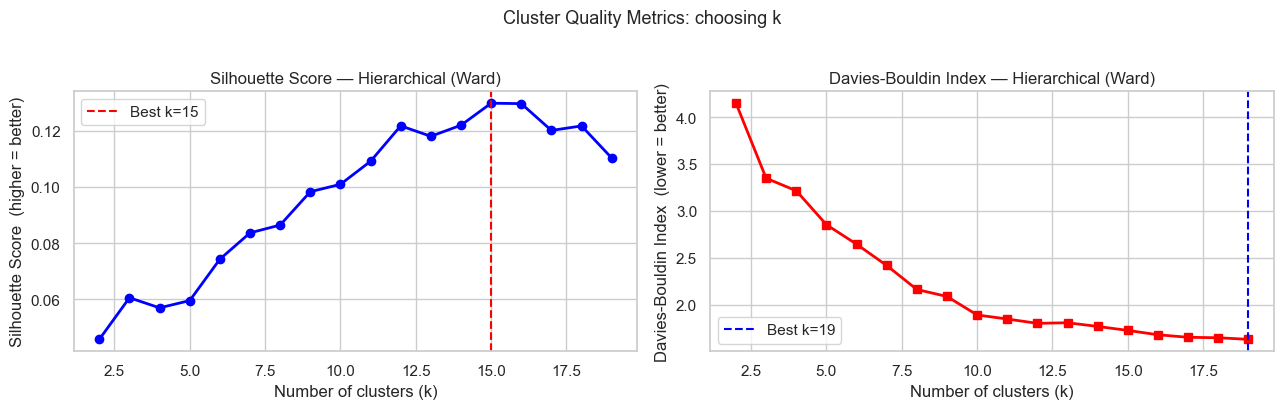

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_range), silhouettes, 'bo-', linewidth=2)
ax1.axvline(x=list(K_range)[np.argmax(silhouettes)], color='red',
            linestyle='--', label=f'Best k={list(K_range)[np.argmax(silhouettes)]}')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Silhouette Score  (higher = better)')
ax1.set_title('Silhouette Score — Hierarchical (Ward)')
ax1.legend()

ax2.plot(list(K_range), db_scores, 'rs-', linewidth=2)
ax2.axvline(x=list(K_range)[np.argmin(db_scores)], color='blue',
            linestyle='--', label=f'Best k={list(K_range)[np.argmin(db_scores)]}')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Davies-Bouldin Index  (lower = better)')
ax2.set_title('Davies-Bouldin Index — Hierarchical (Ward)')
ax2.legend()

plt.suptitle('Cluster Quality Metrics: choosing k', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3b. Fit final hierarchical model
Set `N_CLUSTERS` based on the plots above. Ward linkage is fitted **only on training data** to avoid leakage.

In [30]:
N_CLUSTERS = 10   # <== adjust after inspecting silhouette / DB plots

hc_train = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
train_clusters = hc_train.fit_predict(X_train_scaled)

# Build nearest-centroid classifier so we can assign val/test points
nc = NearestCentroid()
nc.fit(X_train_scaled, train_clusters)

val_clusters  = nc.predict(X_val_scaled)
test_clusters = nc.predict(X_test_scaled)

# Cluster size distribution
unique, counts = np.unique(train_clusters, return_counts=True)
print(f'Final model: Ward linkage, k={N_CLUSTERS}')
print('Cluster sizes (train):')
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n:5d} samples ({n/len(train_clusters)*100:.1f}%)')

Final model: Ward linkage, k=10
Cluster sizes (train):
  Cluster 0:   166 samples (25.7%)
  Cluster 1:   218 samples (33.7%)
  Cluster 2:   109 samples (16.9%)
  Cluster 3:    39 samples (6.0%)
  Cluster 4:    22 samples (3.4%)
  Cluster 5:    31 samples (4.8%)
  Cluster 6:    13 samples (2.0%)
  Cluster 7:     2 samples (0.3%)
  Cluster 8:    45 samples (7.0%)
  Cluster 9:     1 samples (0.2%)


## 4. Cluster Analysis & Economic Interpretation
Inspect cluster centroids and outcome distributions to understand whether clusters map to economically meaningful startup segments.

Outcome distribution per cluster:


,acquired,closed
cluster,,
0,0.614,0.386
1,0.642,0.358
2,0.743,0.257
3,0.667,0.333
4,0.545,0.455
5,0.516,0.484
6,0.308,0.692
7,1.000,0.000
8,0.756,0.244


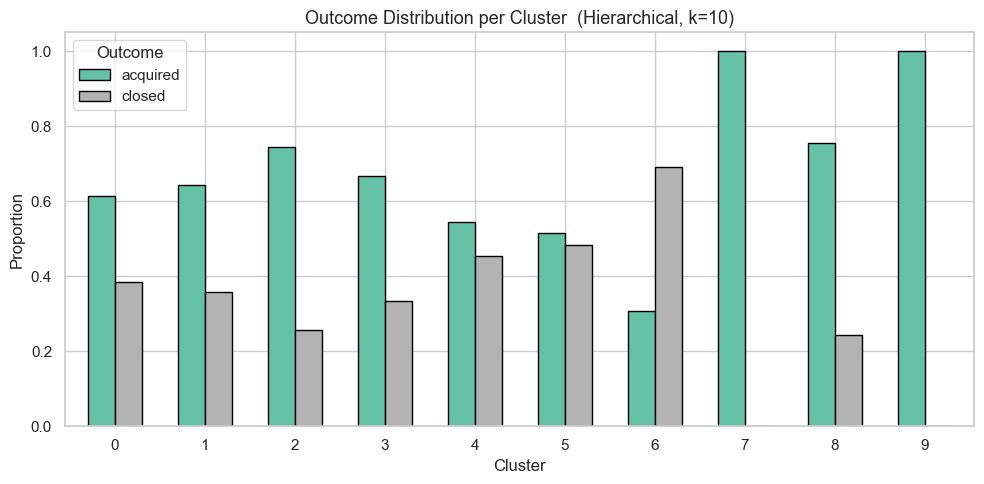

In [31]:
X_train_copy = X_train.copy().reset_index(drop=True)
X_train_copy['cluster'] = train_clusters
X_train_copy['outcome'] = y_train

# --- 4b. Outcome distribution per cluster ---
outcome_dist = (
    X_train_copy.groupby('cluster')['outcome']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
# Rename columns using actual class labels from LabelEncoder
outcome_dist.columns = [le.classes_[c] for c in outcome_dist.columns]
print('Outcome distribution per cluster:')
display(outcome_dist.round(3))

outcome_dist.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black', width=0.6)
plt.title(f'Outcome Distribution per Cluster  (Hierarchical, k={N_CLUSTERS})', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

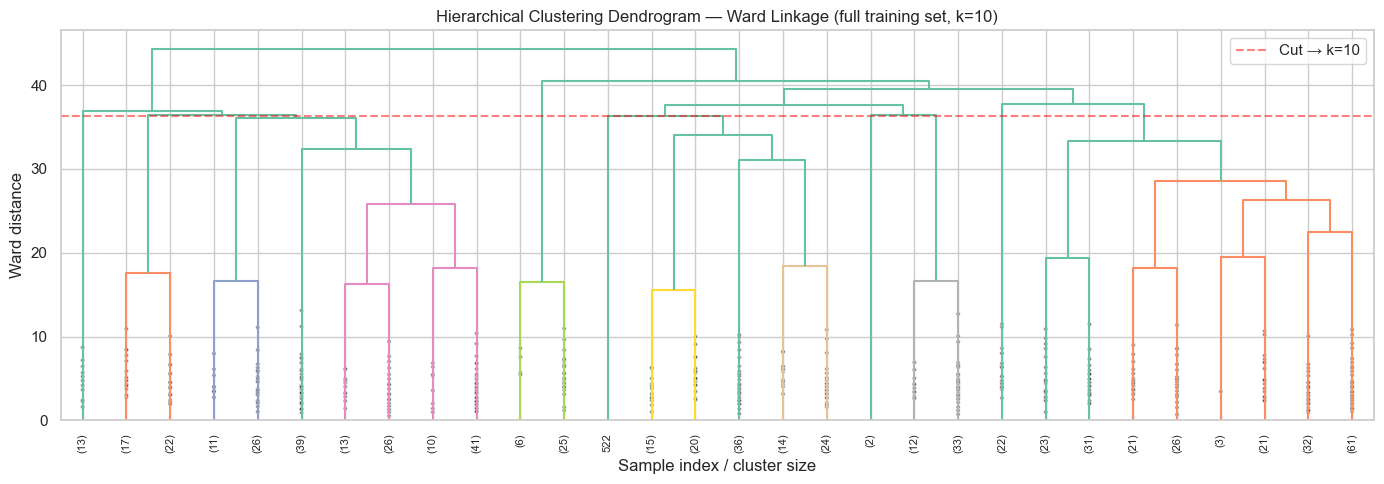

In [32]:
# Dendrogram from final fitted clusters (full training data)
Z_final = linkage(X_train_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z_final, ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    color_threshold=0.7 * max(Z_final[:, 2])
)
ax.set_title(f'Hierarchical Clustering Dendrogram — Ward Linkage (full training set, k={N_CLUSTERS})')
ax.set_xlabel('Sample index / cluster size')
ax.set_ylabel('Ward distance')

# Find the height that produces exactly N_CLUSTERS when the tree is cut there
cut_height = Z_final[-N_CLUSTERS + 1, 2]
ax.axhline(y=cut_height, color='red', linestyle='--', alpha=0.5, label=f'Cut → k={N_CLUSTERS}')
ax.legend()
plt.tight_layout()
plt.show()

# Shows last 30 merges

C:\Users\2same\AppData\Local\Temp\ipykernel_42000\937216772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\2same\AppData\Local\Temp\ipykernel_42000\937216772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\2same\AppData\Local\Temp\ipykernel_42000\937216772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\2same\AppData\Local\Temp\ipykernel_42000\937216772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

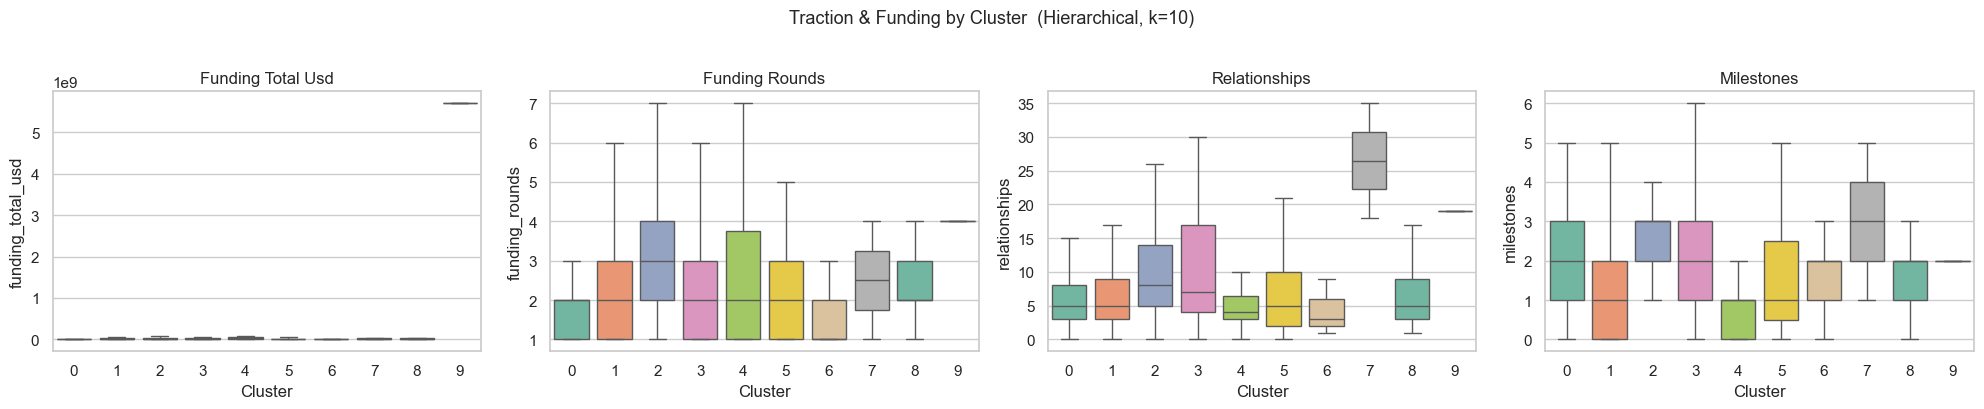

In [33]:
# --- 4d. Funding & traction boxplots per cluster ---
numeric_cols = ['funding_total_usd', 'funding_rounds', 'relationships', 'milestones']
numeric_cols = [c for c in numeric_cols if c in X_train_copy.columns]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        data=X_train_copy, x='cluster', y=col,
        palette='Set2', showfliers=False, ax=ax
    )
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Cluster')

plt.suptitle(f'Traction & Funding by Cluster  (Hierarchical, k={N_CLUSTERS})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Hybrid Model Construction
Cluster labels (one-hot encoded) are appended to the scaled feature matrix — identical strategy to the K-Means hybrid, enabling a fair comparison.

In [34]:
def add_cluster_ohe(X_scaled, clusters, n_clusters):
    """Append one-hot encoded cluster labels to the feature matrix."""
    ohe = np.zeros((len(clusters), n_clusters))
    for i, c in enumerate(clusters):
        ohe[i, c] = 1
    return np.hstack([X_scaled, ohe])

X_train_hybrid = add_cluster_ohe(X_train_scaled, train_clusters, N_CLUSTERS)
X_val_hybrid   = add_cluster_ohe(X_val_scaled,   val_clusters,   N_CLUSTERS)
X_test_hybrid  = add_cluster_ohe(X_test_scaled,  test_clusters,  N_CLUSTERS)

print(f'Hybrid feature matrix shapes:')
print(f'  Train: {X_train_hybrid.shape}  (added {N_CLUSTERS} cluster OHE columns)')
print(f'  Val:   {X_val_hybrid.shape}')
print(f'  Test:  {X_test_hybrid.shape}')

Hybrid feature matrix shapes:
  Train: (646, 44)  (added 10 cluster OHE columns)
  Val:   (138, 44)
  Test:  (139, 44)


In [35]:
# Train hybrid models
lr_hybrid  = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
svm_hybrid = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)

lr_hybrid.fit(X_train_hybrid,  y_train)
svm_hybrid.fit(X_train_hybrid, y_train)

print('Hybrid models trained.')

Hybrid models trained.


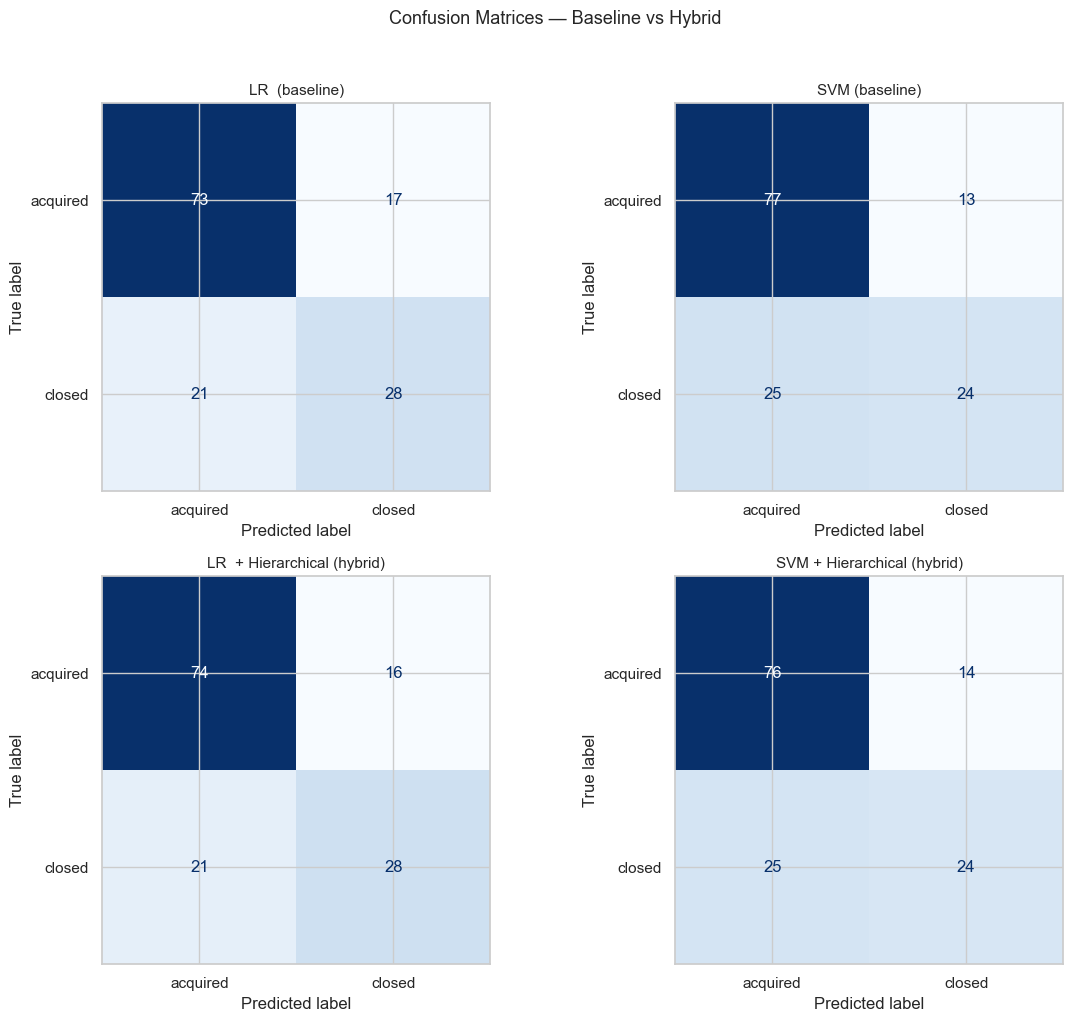

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [
    ('LR  (baseline)',              lr_base,   X_test_scaled),
    ('SVM (baseline)',              svm_base,  X_test_scaled),
    ('LR  + Hierarchical (hybrid)', lr_hybrid, X_test_hybrid),
    ('SVM + Hierarchical (hybrid)', svm_hybrid, X_test_hybrid),
]

for ax, (name, model, X) in zip(axes.flatten(), models):
    cm = confusion_matrix(y_test, model.predict(X))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — Baseline vs Hybrid', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# Evaluate all four models on test set
results.append(evaluate('LR  + Hierarchical (hybrid)',  lr_hybrid,  X_test_hybrid, y_test))
results.append(evaluate('SVM + Hierarchical (hybrid)', svm_hybrid, X_test_hybrid, y_test))


=== LR  + Hierarchical (hybrid) ===
              precision    recall  f1-score   support

    acquired       0.78      0.82      0.80        90
      closed       0.64      0.57      0.60        49

    accuracy                           0.73       139
   macro avg       0.71      0.70      0.70       139
weighted avg       0.73      0.73      0.73       139

F1 Macro: 0.7011   ROC-AUC: 0.7807

=== SVM + Hierarchical (hybrid) ===
              precision    recall  f1-score   support

    acquired       0.75      0.84      0.80        90
      closed       0.63      0.49      0.55        49

    accuracy                           0.72       139
   macro avg       0.69      0.67      0.67       139
weighted avg       0.71      0.72      0.71       139

F1 Macro: 0.6738   ROC-AUC: 0.7222


## 6. K-Fold Cross-Validation

**Why CV makes sense here:** With only ~923 total samples, the train set (~646 rows) is small enough that a single split produces noisy estimates. CV gives a more reliable performance estimate.

**The leakage trap to avoid:** We cannot fit hierarchical clustering on the full training set and then cross-validate just the classifier — that would leak information from each held-out fold into the cluster labels. Instead, each fold re-runs the *entire* pipeline independently:

```
For each fold:
  1. Fit StandardScaler on fold train set
  2. Fit AgglomerativeClustering on scaled fold train set
  3. Assign fold val points via NearestCentroid
  4. Build hybrid features (scaled + OHE clusters)
  5. Fit LR / SVM on hybrid train, evaluate on hybrid val
```

We run CV on `X_train` (the 70% split) and keep `X_test` untouched as the final held-out set.

In [38]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS   = 10
CV_K      = N_CLUSTERS   # use the same k chosen in Section 3

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Store per-fold scores for all four model variants
cv_scores = {
    'LR  (baseline)':              {'f1': [], 'auc': []},
    'SVM (baseline)':              {'f1': [], 'auc': []},
    'LR  + Hierarchical (hybrid)': {'f1': [], 'auc': []},
    'SVM + Hierarchical (hybrid)': {'f1': [], 'auc': []},
}

X_train_arr = np.array(X_train)   # ensure numpy for indexing
y_train_arr = np.array(y_train)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_vl = X_train_arr[tr_idx], X_train_arr[val_idx]
    y_tr, y_vl = y_train_arr[tr_idx], y_train_arr[val_idx]

    # 1. Scale — fit only on fold train
    fold_scaler = StandardScaler()
    X_tr_s = fold_scaler.fit_transform(X_tr)
    X_vl_s = fold_scaler.transform(X_vl)

    # 2. Cluster — fit only on fold train
    fold_hc = AgglomerativeClustering(n_clusters=CV_K, linkage='ward')
    tr_clusters = fold_hc.fit_predict(X_tr_s)

    # 3. Assign val points via NearestCentroid
    fold_nc = NearestCentroid()
    fold_nc.fit(X_tr_s, tr_clusters)
    vl_clusters = fold_nc.predict(X_vl_s)

    # 4. Build hybrid features
    X_tr_hyb = add_cluster_ohe(X_tr_s, tr_clusters, CV_K)
    X_vl_hyb = add_cluster_ohe(X_vl_s, vl_clusters, CV_K)

    # 5. Fit & evaluate all four variants
    fold_models = {
        'LR  (baseline)':              (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_tr_s,   X_vl_s),
        'SVM (baseline)':              (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),  X_tr_s,   X_vl_s),
        'LR  + Hierarchical (hybrid)': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_tr_hyb, X_vl_hyb),
        'SVM + Hierarchical (hybrid)': (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),  X_tr_hyb, X_vl_hyb),
    }

    for name, (model, X_fit, X_eval) in fold_models.items():
        model.fit(X_fit, y_tr)
        y_pred = model.predict(X_eval)
        y_prob = model.predict_proba(X_eval)[:, 1]
        cv_scores[name]['f1'].append(f1_score(y_vl, y_pred, average='macro'))
        cv_scores[name]['auc'].append(roc_auc_score(y_vl, y_prob))

    print(f'Fold {fold} done.')

print('Cross-validation complete.')

Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.
Fold 6 done.
Fold 7 done.
Fold 8 done.
Fold 9 done.
Fold 10 done.
Cross-validation complete.


In [39]:
# Summarise CV results
cv_rows = []
for name, scores in cv_scores.items():
    cv_rows.append({
        'Model':        name,
        'F1 Mean':      np.mean(scores['f1']),
        'F1 Std':       np.std(scores['f1']),
        'AUC Mean':     np.mean(scores['auc']),
        'AUC Std':      np.std(scores['auc']),
    })

cv_df = pd.DataFrame(cv_rows).set_index('Model').round(4)
print(f'=== {N_FOLDS}-Fold Stratified CV Results (on X_train, k={CV_K}) ===')
display(cv_df)

=== 10-Fold Stratified CV Results (on X_train, k=10) ===


,F1 Mean,F1 Std,AUC Mean,AUC Std
Model,,,,
LR (baseline),0.7301,0.0406,0.8107,0.0455
SVM (baseline),0.7232,0.0221,0.8078,0.0441
LR + Hierarchical (hybrid),0.7410,0.0364,0.8123,0.0452
SVM + Hierarchical (hybrid),0.7253,0.0224,0.8066,0.0441


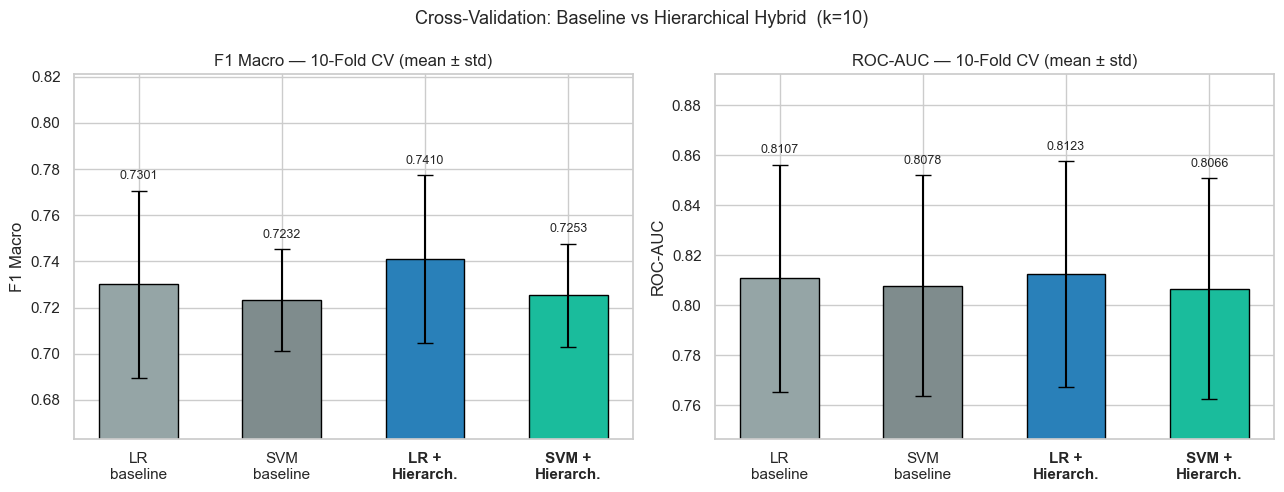

In [40]:
# Plot CV F1 and AUC with error bars (std)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#95a5a6', '#7f8c8d', '#2980b9', '#1abc9c']
model_names = list(cv_scores.keys())
short_names = ['LR\nbaseline', 'SVM\nbaseline', 'LR +\nHierarch.', 'SVM +\nHierarch.']

for ax, metric_mean, metric_std, label in [
    (axes[0], 'F1 Mean',  'F1 Std',  'F1 Macro'),
    (axes[1], 'AUC Mean', 'AUC Std', 'ROC-AUC'),
]:
    means = cv_df[metric_mean].values
    stds  = cv_df[metric_std].values
    bars  = ax.bar(short_names, means, yerr=stds, capsize=6,
                   color=colors, edgecolor='black', width=0.55,
                   error_kw=dict(elinewidth=1.5, ecolor='black'))
    ax.bar_label(bars, labels=[f'{m:.4f}' for m in means], padding=6, fontsize=9)
    ax.set_ylim(means.min() - 0.06, means.max() + 0.08)
    ax.set_ylabel(label)
    ax.set_title(f'{label} — {N_FOLDS}-Fold CV (mean ± std)')
    # Bold hybrid bars' tick labels
    for tick, name in zip(ax.get_xticklabels(), short_names):
        if 'Hierarch' in name:
            tick.set_fontweight('bold')

plt.suptitle(f'Cross-Validation: Baseline vs Hierarchical Hybrid  (k={CV_K})', fontsize=13)
plt.tight_layout()
plt.show()

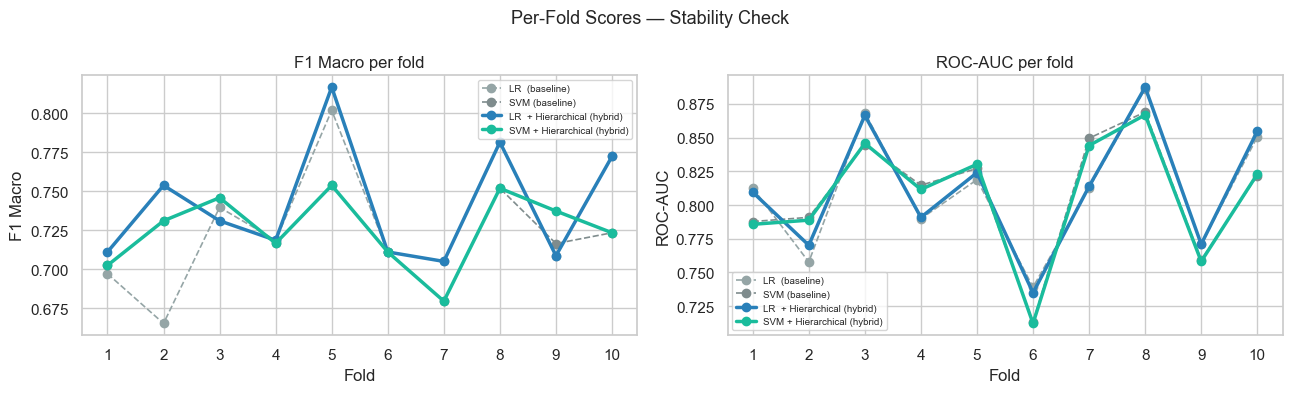

In [41]:
# Per-fold line plot — shows variance across folds
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, label in [(axes[0], 'f1', 'F1 Macro'), (axes[1], 'auc', 'ROC-AUC')]:
    for name, col in zip(model_names, colors):
        lw = 2.5 if 'hybrid' in name.lower() else 1.2
        ls = '-'  if 'hybrid' in name.lower() else '--'
        ax.plot(range(1, N_FOLDS + 1), cv_scores[name][metric],
                marker='o', linewidth=lw, linestyle=ls, color=col,
                label=name)
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_title(f'{label} per fold')
    ax.set_xticks(range(1, N_FOLDS + 1))
    ax.legend(fontsize=7)

plt.suptitle('Per-Fold Scores — Stability Check', fontsize=13)
plt.tight_layout()
plt.show()